In [7]:
# # Project 2: Olist E-Commerce Analytics
# **Analyst:** Sachin Malee
# **Dataset:** Brazilian E-Commerce (Kaggle/Olist)
# **Tools:** Python, Pandas, Matplotlib, Seaborn

In [13]:
# ================================================
# Libraries
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ Libraries imported!")

✅ Libraries imported!


In [14]:
# ================================================
# Load Data
# ================================================

path = "C:/Users/srmal/OneDrive/Desktop/olist_projects/"

customers   = pd.read_csv(path +
    'olist_customers_dataset.csv')
orders      = pd.read_csv(path +
    'olist_orders_dataset.csv')
order_items = pd.read_csv(path +
    'olist_order_items_dataset.csv')
payments    = pd.read_csv(path +
    'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(path +
    'olist_order_reviews_dataset.csv')
products    = pd.read_csv(path +
    'olist_products_dataset.csv')
sellers     = pd.read_csv(path +
    'olist_sellers_dataset.csv')
translation = pd.read_csv(path +
    'product_category_name_translation.csv')

print("✅ Data loaded!")
print(f"Orders:      {len(orders):,}")
print(f"Customers:   {len(customers):,}")
print(f"Order Items: {len(order_items):,}")
print(f"Payments:    {len(payments):,}")
print(f"Reviews:     {len(reviews):,}")
print(f"Products:    {len(products):,}")
print(f"Sellers:     {len(sellers):,}")

✅ Data loaded!
Orders:      99,441
Customers:   99,441
Order Items: 112,650
Payments:    103,886
Reviews:     99,224
Products:    32,951
Sellers:     3,095


In [15]:
# ================================================
# Data Cleaning
# ================================================

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(
        orders[col], errors='coerce')


orders_del = orders[
    orders['order_status'] == 'delivered'
].copy()


orders_del['order_month'] = (
    orders_del['order_purchase_timestamp']
    .dt.to_period('M'))

orders_del['delivery_days'] = (
    orders_del['order_delivered_customer_date'] -
    orders_del['order_purchase_timestamp']
).dt.days

orders_del['is_late'] = (
    orders_del['order_delivered_customer_date'] >
    orders_del['order_estimated_delivery_date']
).astype(int)


products_eng = products.merge(
    translation,
    on='product_category_name',
    how='left')

products_eng['category'] = (
    products_eng[
        'product_category_name_english']
    .fillna(products_eng[
        'product_category_name'])
    .fillna('Unknown'))

print("✅ Cleaning done!")
print(f"Delivered orders: {len(orders_del):,}")
print(f"Late deliveries:  "
      f"{orders_del['is_late'].sum():,} "
      f"({orders_del['is_late'].mean()*100:.1f}%)")

✅ Cleaning done!
Delivered orders: 96,478
Late deliveries:  7,826 (8.1%)


In [16]:
# ================================================
# Master DataFrame
# ================================================

master = (orders_del
    .merge(customers,    on='customer_id',  how='left')
    .merge(payments,     on='order_id',     how='left')
    .merge(order_items,  on='order_id',     how='left')
    .merge(products_eng, on='product_id',   how='left')
    .merge(sellers,      on='seller_id',    how='left')
)

print(f"✅ Master DataFrame:")
print(f"   Rows:    {len(master):,}")
print(f"   Columns: {len(master.columns)}")

✅ Master DataFrame:
   Rows:    115,038
   Columns: 38


In [17]:
# ================================================
# RFM Analysis
# ================================================

snapshot = pd.Timestamp('2018-10-17')

rfm = (orders_del
    .merge(customers, on='customer_id')
    .merge(payments,  on='order_id')
    .groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp',
                     lambda x: (snapshot - x.max()).days),
        frequency = ('order_id', 'nunique'),
        monetary  = ('payment_value', 'sum'))
    .reset_index()
)

rfm['r_score'] = pd.qcut(
    rfm['recency'], 5,
    labels=[5,4,3,2,1],
    duplicates='drop')

rfm['f_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5, labels=[1,2,3,4,5])

rfm['m_score'] = pd.qcut(
    rfm['monetary'], 5,
    labels=[1,2,3,4,5],
    duplicates='drop')

rfm['rfm_score'] = (
    rfm['r_score'].astype(int) +
    rfm['f_score'].astype(int) +
    rfm['m_score'].astype(int))

rfm['segment'] = pd.cut(
    rfm['rfm_score'],
    bins=[0, 5, 8, 11, 15],
    labels=['Lost','At Risk',
            'Loyal','Champion'])

print("✅ RFM Analysis done!")
print(rfm['segment'].value_counts())

✅ RFM Analysis done!
segment
Loyal       38440
At Risk     31857
Champion    15283
Lost         7650
Name: count, dtype: int64


In [18]:
# ================================================
# Key Insights
# ================================================

print("="*55)
print("📊 OLIST E-COMMERCE — KEY INSIGHTS")
print("="*55)

print(f"\n💰 Total Revenue:      "
      f"R${master['payment_value'].sum():,.0f}")
print(f"📦 Total Orders:       "
      f"{orders_del['order_id'].nunique():,}")
print(f"👥 Unique Customers:   "
      f"{customers['customer_unique_id'].nunique():,}")
print(f"🏪 Active Sellers:     "
      f"{sellers['seller_id'].nunique():,}")
print(f"⏱️  Avg Delivery Days:  "
      f"{orders_del['delivery_days'].mean():.1f}")
print(f"🚨 Late Delivery Rate: "
      f"{orders_del['is_late'].mean()*100:.1f}%")
print(f"⭐ Avg Review Score:   "
      f"{reviews['review_score'].mean():.2f}/5")

repeat = (rfm['frequency'] > 1).sum()
total  = len(rfm)
print(f"\n🔄 Repeat Buyers: "
      f"{repeat:,} ({repeat/total*100:.1f}%)")
print(f"1️⃣  One-Time:      "
      f"{total-repeat:,} "
      f"({(total-repeat)/total*100:.1f}%)")

📊 OLIST E-COMMERCE — KEY INSIGHTS

💰 Total Revenue:      R$19,776,160
📦 Total Orders:       96,478
👥 Unique Customers:   96,096
🏪 Active Sellers:     3,095
⏱️  Avg Delivery Days:  12.1
🚨 Late Delivery Rate: 8.1%
⭐ Avg Review Score:   4.09/5

🔄 Repeat Buyers: 0 (0.0%)
1️⃣  One-Time:      93,230 (100.0%)


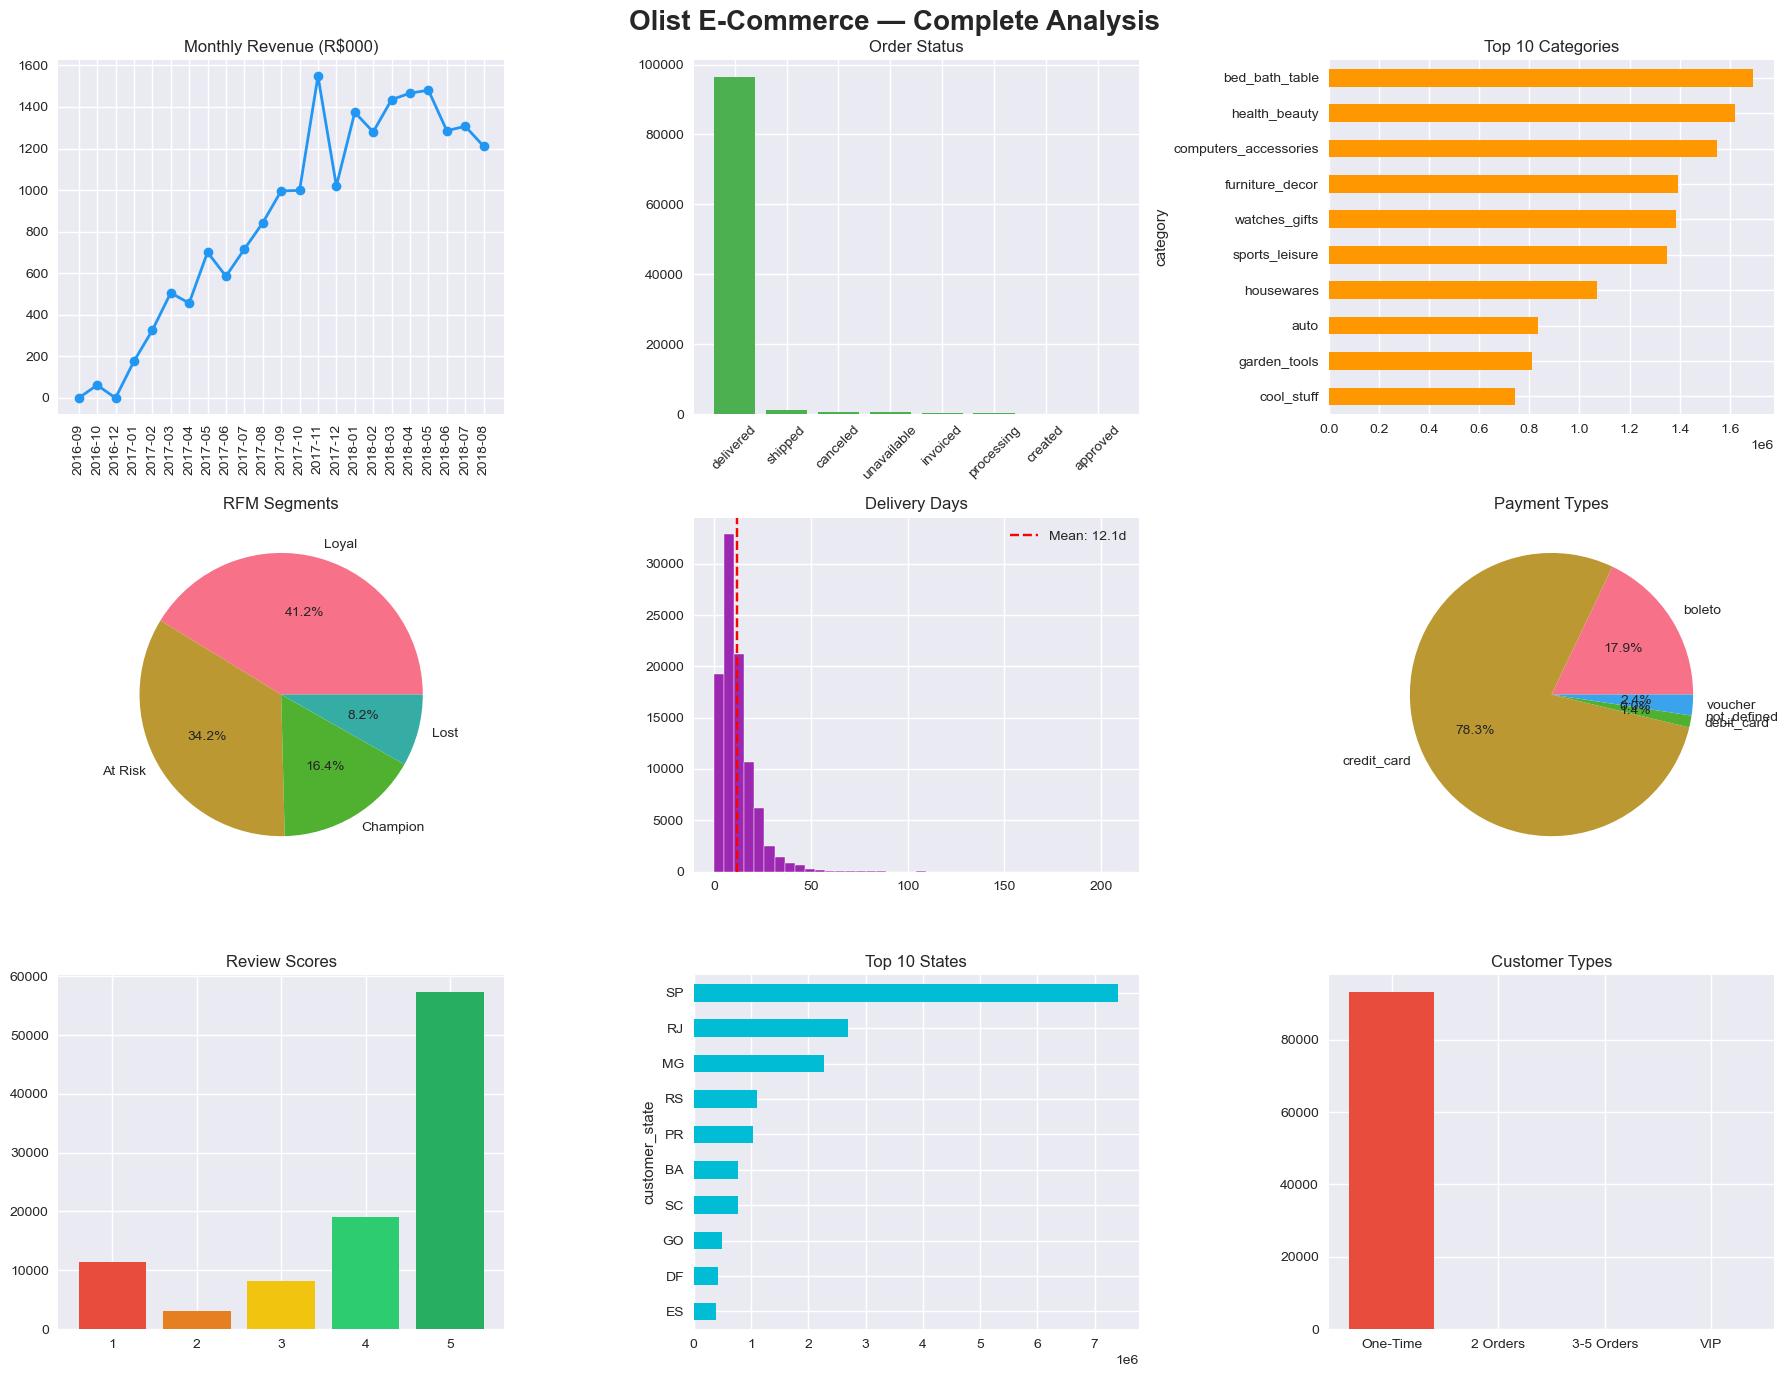

✅ All graphs saved!


In [19]:
# ================================================
# Visualizations
# ================================================

fig, axes = plt.subplots(3, 3,
    figsize=(18, 14))
fig.suptitle(
    'Olist E-Commerce — Complete Analysis',
    fontsize=20, fontweight='bold')

# Graph 1 — Monthly Revenue
monthly = (master
    .groupby('order_month')
    ['payment_value'].sum()
    .reset_index())
monthly['order_month'] = (
    monthly['order_month'].astype(str))
axes[0,0].plot(
    monthly['order_month'],
    monthly['payment_value']/1000,
    marker='o', color='#2196F3',
    linewidth=2)
axes[0,0].set_title('Monthly Revenue (R$000)')
axes[0,0].tick_params(axis='x', rotation=90)

# Graph 2 — Order Status
status = orders['order_status'].value_counts()
axes[0,1].bar(status.index, status.values,
              color='#4CAF50')
axes[0,1].set_title('Order Status')
axes[0,1].tick_params(axis='x', rotation=45)

# Graph 3 — Top 10 Categories
top_cat = (master
    .groupby('category')
    ['payment_value'].sum()
    .nlargest(10).sort_values())
top_cat.plot(kind='barh',
             ax=axes[0,2],
             color='#FF9800')
axes[0,2].set_title('Top 10 Categories')

# Graph 4 — RFM Segments
seg = rfm['segment'].value_counts()
axes[1,0].pie(seg.values,
              labels=seg.index,
              autopct='%1.1f%%')
axes[1,0].set_title('RFM Segments')

# Graph 5 — Delivery Days
del_days = orders_del[
    'delivery_days'].dropna()
axes[1,1].hist(del_days, bins=40,
               color='#9C27B0',
               edgecolor='white')
axes[1,1].axvline(
    del_days.mean(),
    color='red', linestyle='--',
    label=f'Mean: {del_days.mean():.1f}d')
axes[1,1].set_title('Delivery Days')
axes[1,1].legend()

# Graph 6 — Payment Types
pay = (payments
    .groupby('payment_type')
    ['payment_value'].sum())
axes[1,2].pie(pay.values,
              labels=pay.index,
              autopct='%1.1f%%')
axes[1,2].set_title('Payment Types')

# Graph 7 — Review Scores
scores = (reviews['review_score']
    .value_counts().sort_index())
colors = ['#e74c3c','#e67e22',
          '#f1c40f','#2ecc71','#27ae60']
axes[2,0].bar(scores.index,
              scores.values,
              color=colors)
axes[2,0].set_title('Review Scores')

# Graph 8 — Top States
state = (master
    .groupby('customer_state')
    ['payment_value'].sum()
    .nlargest(10).sort_values())
state.plot(kind='barh',
           ax=axes[2,1],
           color='#00BCD4')
axes[2,1].set_title('Top 10 States')

# Graph 9 — Repeat vs One-Time
buyer_type = pd.cut(
    rfm['frequency'],
    bins=[0,1,2,5,100],
    labels=['One-Time','2 Orders',
            '3-5 Orders','VIP'])
buyer_counts = buyer_type.value_counts()
axes[2,2].bar(
    buyer_counts.index,
    buyer_counts.values,
    color=['#e74c3c','#f39c12',
           '#3498db','#2ecc71'])
axes[2,2].set_title('Customer Types')

plt.tight_layout()
plt.savefig('olist_analysis.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ All graphs saved!")